<a href="https://colab.research.google.com/github/Thashmikab/offshore-wind-layout-cable-tradeoff/blob/main/07_BrightWay_Impact_Assessment_and_Techno_Environmental_Optimisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install -q py_wake==2.6.20 topfarm==2.6.2 pymoo==0.6.2

In [2]:
!pip install brightway25

In [3]:
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import minimum_spanning_tree
import numpy as np
import xarray as xr
from py_wake.site import XRSite
from py_wake.site.xrsite import GlobalWindAtlasSite
from py_wake.examples.data.dtu10mw import DTU10MW
from py_wake.literature.gaussian_models import Niayifar_PorteAgel_2016
from py_wake.wind_farm_models import PropagateDownwind
from py_wake.turbulence_models import CrespoHernandez
#from py_wake.wind_farm_models import EngineeringWindFarmModel
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.core.problem import Problem

import bw2io as bi
import bw2data as bd
import bw2calc as bc
import pandas as pd
import brightway25 as bw


from google.colab import userdata

/usr/local/lib/python3.13/dist-packages/bw2calc/__init__.py:57: UserWarning: 
It seems like you have an AMD/INTEL x64 architecture, but haven't installed pypardiso:

    https://pypi.org/project/pypardiso/

Installing it could give you much faster calculations.

  warnings.warn(PYPARDISO_WARNING)
/usr/local/lib/python3.13/dist-packages/brightway25/__init__.py:9: UserWarning: The Brightway25 package doesn't provide anything; import the constituent libraries separately
  warnings.warn("The Brightway25 package doesn't provide anything; import the constituent libraries separately")


In [8]:
#@title Turbine mass model (Li et al., 2022)
# Size relations: Li et al. (2022) SI, Fig. S2 (published equations)
# Component masses: power laws fitted to Li et al. (2022) SI, Fig. S3 (digitised by the author, ~±10%)

def rotor_diameter(C_mw):
    return 62.69 * C_mw ** 0.46

def hub_height(D_m):
    return 4.93 * (D_m ** 2) ** 0.31

def component_masses_t(C_mw, foundation="jacket"):
    D = rotor_diameter(C_mw)
    H = hub_height(D)
    masses = {
        "nacelle": 285 * (D / 148) ** 2.14,           # geared PMSG
        "rotor":   165 * (D / 148) ** 2.56,           # glass-fibre blades + hub
        "tower":   390 * (D**2 * H / 2.3e6) ** 0.69,  # steel tower
    }
    if foundation == "jacket":
        masses["foundation"] = 1150 * (C_mw / 6.5) ** 1.255
    else:
        masses["foundation"] = 1700 * (C_mw / 6.5) ** 1.235   # monopile
    return D, H, masses




# Share of component mass by material class (Li et al. 2022, Table 1)
COMPOSITION = {
    "nacelle":    {"cast_iron": 0.415, "steel_high_alloy": 0.393, "steel_low_alloy": 0.103,
                   "copper": 0.022, "aluminium": 0.009, "electronics": 0.004},   # PMSG-GB
    "rotor":      {"cast_iron": 0.258, "steel_high_alloy": 0.094, "steel_low_alloy": 0.098,
                   "copper": 0.001, "aluminium": 0.001, "glass_fibre": 0.373, "resin": 0.175},
    "tower":      {"steel_low_alloy": 0.971, "copper": 0.009, "aluminium": 0.010, "electronics": 0.010},
    "foundation": {"steel_low_alloy": 0.858, "concrete": 0.142},                  # jacket
}

In [43]:
#@title Setting up the new brightway project


bd.projects.set_current("Offshore")

EI_USER, EI_PASS = userdata.get("ECOINVENT_USER"), userdata.get("ECOINVENT_PASS")


if "ecoinvent-3.9.1-apos" not in bd.databases:
    bi.import_ecoinvent_release(
        version='3.9.1',
        system_model='apos',        # can be cutoff / apos / consequential / EN15804
        username= EI_USER,
        password= EI_PASS
    )


In [48]:
#@title Find ecoinvent activities (checks every name)


ei = bd.Database("ecoinvent-3.9.1-apos")
LOCATION_PREFERENCE = ["GLO", "RER", "Europe without Switzerland", "RoW"]

def find(name):
    hits = [a for a in ei if a["name"] == name]
    if not hits:
        raise ValueError(f"Not found in ecoinvent: '{name}' - search with ei.search() and fix the name")
    hits.sort(key=lambda a: LOCATION_PREFERENCE.index(a["location"])
              if a["location"] in LOCATION_PREFERENCE else 99)
    return hits[0]

CONCRETE_DENSITY = 2400   # kg/m3 (assumption)

# material class -> list of (activity name, amount per kg of material)
MAPPING = {
    "steel_low_alloy":  [("market for steel, low-alloyed", 1),
                         ("market for hot rolling, steel", 1)],
    "steel_high_alloy": [("market for steel, chromium steel 18/8", 1),
                         ("market for metal working, average for chromium steel product manufacturing", 1)],
    "cast_iron":        [("market for cast iron", 1),
                         ("market for metal working, average for steel product manufacturing", 1)],
    "copper":           [("market for copper, cathode", 1),
                         ("market for wire drawing, copper", 1)],
    "aluminium":        [("market for aluminium, wrought alloy", 1),
                         ("market for sheet rolling, aluminium", 1)],
    "glass_fibre":      [("market for glass fibre", 1)],
    "resin":            [("market for epoxy resin, liquid", 1)],
    "electronics":      [("market for electronics, for control units", 1)],
    "concrete":         [("market for concrete, normal strength", 1 / CONCRETE_DENSITY)],
    "lead":          [("market for lead", 1)],
    "steel_armour":  [("market for steel, low-alloyed", 1), ("market for wire drawing, steel", 1)],
    "xlpe":          [("market for polyethylene, low density, granulate", 1),
                      ("market for extrusion, plastic pipes", 1)],
    "polymer_other": [("market for polypropylene, granulate", 1)],
}

# Resolve every name first, so all problems show up at once
resolved = {}
for material, steps in MAPPING.items():
    resolved[material] = [(find(name), amount) for name, amount in steps]
    for act, amount in resolved[material]:
        print(f"{material:18s} | {act['name']} | {act['location']} | {act['unit']}")

steel_low_alloy    | market for steel, low-alloyed | GLO | kilogram
steel_low_alloy    | market for hot rolling, steel | GLO | kilogram
steel_high_alloy   | market for steel, chromium steel 18/8 | GLO | kilogram
steel_high_alloy   | market for metal working, average for chromium steel product manufacturing | GLO | kilogram
cast_iron          | market for cast iron | GLO | kilogram
cast_iron          | market for metal working, average for steel product manufacturing | GLO | kilogram
copper             | market for copper, cathode | GLO | kilogram
copper             | market for wire drawing, copper | GLO | kilogram
aluminium          | market for aluminium, wrought alloy | GLO | kilogram
aluminium          | market for sheet rolling, aluminium | GLO | kilogram
glass_fibre        | market for glass fibre | GLO | kilogram
resin              | market for epoxy resin, liquid | RER | kilogram
electronics        | market for electronics, for control units | GLO | kilogram
concrete           

In [49]:
#@title List the ReCiPe midpoint (H) categories
MIDPOINT = "ReCiPe 2016 v1.03, midpoint (H)"      # exact match: excludes the "no LT" variants
recipe = [m for m in bd.methods if m[1] == MIDPOINT]


In [50]:
#@title Impact per kg of each material class
# short name -> start of the ReCiPe category name (check against the list above)
CATEGORIES = {
    "GWP100": "climate change",
    "SOP":    "material resources: metals/minerals",
    "water":  "water use",
    "TETP":   "ecotoxicity: terrestrial",
}

METHODS, UNITS = {}, {}
for short, category in CATEGORIES.items():
    hits = [m for m in recipe if m[2].startswith(category)]
    assert len(hits) == 1, f"{short}: expected one method, found {hits}"
    METHODS[short] = hits[0]
    UNITS[short] = bd.Method(hits[0]).metadata.get("unit")
    print(short, "->", hits[0][2], "|", hits[0][3], "|", UNITS[short])

def impact(activity, amount, method):
    fu, data_objs, _ = bd.prepare_lca_inputs({activity: amount}, method=method)
    lca = bc.LCA(fu, data_objs=data_objs)
    lca.lci(); lca.lcia()
    return lca.score

rows = {}
for material, steps in resolved.items():
    rows[material] = {short: sum(impact(act, amount, method) for act, amount in steps)
                      for short, method in METHODS.items()}

IMPACT_PER_KG = pd.DataFrame(rows).T          # rows: materials, columns: categories
IMPACT_PER_KG.columns = [f"{c} ({UNITS[c]}/kg)" for c in IMPACT_PER_KG.columns]
print(IMPACT_PER_KG.round(4).to_string())

GWP100 -> climate change | global warming potential (GWP100) | kg CO2-Eq
SOP -> material resources: metals/minerals | surplus ore potential (SOP) | kg Cu-Eq
water -> water use | water consumption potential (WCP) | m3
TETP -> ecotoxicity: terrestrial | terrestrial ecotoxicity potential (TETP) | kg 1,4-DCB-Eq
                  GWP100 (kg CO2-Eq/kg)  SOP (kg Cu-Eq/kg)  water (m3/kg)  TETP (kg 1,4-DCB-Eq/kg)
steel_low_alloy                  2.5666             0.3488         0.0236                  14.2226
steel_high_alloy                 7.9848             0.6452         0.0503                 205.9388
cast_iron                        4.1878             0.4122         0.0231                  21.1420
copper                           8.2903             1.8376         0.1508                3379.6761
aluminium                       15.0434             0.2288         0.0886                  16.9804
glass_fibre                      2.6044             0.0546         0.0162                  28.884

In [89]:
#@title Impacts of one turbine (materials + processing)
PER_KG = {c: IMPACT_PER_KG.iloc[:, i].to_dict() for i, c in enumerate(METHODS)}

def turbine_impacts(C_mw, foundation="jacket"):
    D, H, masses = component_masses_t(C_mw, foundation)
    totals = {c: 0.0 for c in METHODS}
    for component, mass_t in masses.items():
        for material, share in COMPOSITION[component].items():
            for c in METHODS:
                totals[c] += mass_t * 1000 * share * PER_KG[c][material]
    return totals

for C in [8, 10, 12]:
    t = turbine_impacts(C)
    print(f"{C} MW | " + " | ".join(f"{c}: {v / C:,.0f} {UNITS[c]}/MW" for c, v in t.items()))

8 MW | GWP100: 946,457 kg CO2-Eq/MW | SOP: 107,120 kg Cu-Eq/MW | water: 7,891 m3/MW | TETP: 13,801,099 kg 1,4-DCB-Eq/MW
10 MW | GWP100: 967,380 kg CO2-Eq/MW | SOP: 109,757 kg Cu-Eq/MW | water: 8,078 m3/MW | TETP: 13,846,354 kg 1,4-DCB-Eq/MW
12 MW | GWP100: 985,840 kg CO2-Eq/MW | SOP: 112,085 kg Cu-Eq/MW | water: 8,243 m3/MW | TETP: 13,893,624 kg 1,4-DCB-Eq/MW


                  mass_share  GWP100   SOP  water  TETP
cast_iron                7.8    10.9   9.5    7.2   3.9
steel_high_alloy         6.1    16.3  11.6   12.3  29.4
steel_low_alloy         71.8    61.7  73.9   67.9  23.9
copper                   0.5     1.3   2.5    2.8  36.8
aluminium                0.3     1.6   0.2    1.1   0.1
electronics              0.2     2.6   1.1    2.6   3.0
glass_fibre              3.2     2.8   0.5    2.1   2.1
resin                    1.5     2.5   0.6    3.8   0.7
concrete                 8.7     0.4   0.1    0.1   0.1


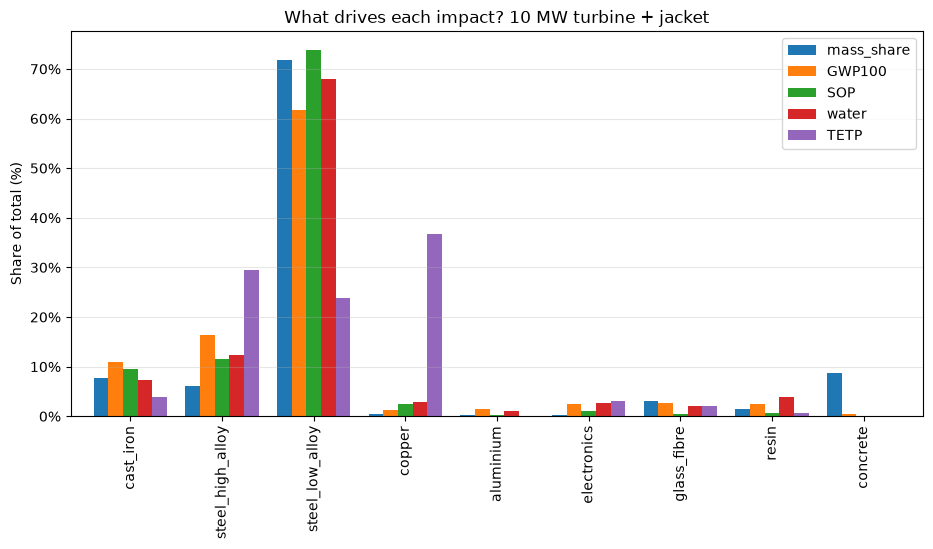

In [52]:
#@title Contribution by material (10 MW turbine)
def contributions(C_mw, foundation="jacket"):
    D, H, masses = component_masses_t(C_mw, foundation)
    material_kg = {}
    for component, mass_t in masses.items():
        for material, share in COMPOSITION[component].items():
            material_kg[material] = material_kg.get(material, 0) + mass_t * 1000 * share
    rows = {m: {c: kg * PER_KG[c][m] for c in METHODS} for m, kg in material_kg.items()}
    df = pd.DataFrame(rows).T
    df.insert(0, "mass_share", pd.Series(material_kg) / sum(material_kg.values()))
    return df / df.sum()                      # everything as a share of the total

share = contributions(10)
print((share * 100).round(1).to_string())

share.plot.bar(figsize=(11, 5), width=0.8)
plt.ylabel("Share of total (%)")
plt.title("What drives each impact? 10 MW turbine + jacket")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
plt.grid(axis="y", alpha=0.3)
#plt.savefig(FIG / "07_contribution_by_material.png", dpi=150, bbox_inches="tight")
plt.show()

In [44]:
#@title Cable material inventory from ABB (2010) geometry, per metre
RHO = {"copper": 8960, "lead": 11340, "steel": 7850, "xlpe": 950}   # kg/m3

# ABB "XLPE Submarine Cable Systems" rev 5, three-core cables with lead sheath (Tables 45, 47, 49)
# name: (conductor mm2, conductor dia mm, dia over insulation mm, lead thickness mm, outer dia mm, weight Cu kg/m, armour wire mm)
CABLES = {
    "array_66kV_3x400":   (400, 23.2, 43.6, 1.7, 141, 39.2, 5),
    "export_132kV_3x300": (300, 20.4, 54.8, 2.1, 167, 48.0, 5),
    "export_220kV_3x1000":(1000, 37.9, 87.3, 3.1, 241, 104.0, 6),
}

def cable_materials_kg_per_m(A, d_cond, d_ins, t_lead, OD, weight, wire, serving=4.0, lay=1.03):
    m = {}
    m["copper"] = 3 * A * 1e-6 * RHO["copper"]
    m["xlpe"]   = 3 * np.pi / 4 * (d_ins**2 - d_cond**2) * 1e-6 * RHO["xlpe"]
    m["lead"]   = 3 * np.pi * (d_ins + t_lead) * t_lead * 1e-6 * RHO["lead"]
    D_mean = OD - 2 * serving - wire                                  # armour layer mid-diameter
    m["steel_armour"] = np.pi * D_mean * np.pi * wire / 4 * 1e-6 * RHO["steel"] * lay
    m["polymer_other"] = weight - sum(m.values())                     # fillers, sheaths, serving
    return m

CABLE_KG_PER_M = pd.DataFrame({k: cable_materials_kg_per_m(*v) for k, v in CABLES.items()}).T
print((CABLE_KG_PER_M).round(2).to_string())       # kg/m = t/km

                     copper   xlpe   lead  steel_armour  polymer_other
array_66kV_3x400      10.75   3.05   8.23         12.77           4.40
export_132kV_3x300     8.06   5.79  12.77         15.36           6.01
export_220kV_3x1000   26.88  13.84  29.95         27.17           6.15


In [53]:
#@title Cable impacts per km
CABLE_IMPACT_PER_KM = {
    cable: {c: sum(CABLE_KG_PER_M.loc[cable, m] * 1000 * PER_KG[c][m]      # kg/m -> kg/km
                   for m in CABLE_KG_PER_M.columns)
            for c in METHODS}
    for cable in CABLE_KG_PER_M.index
}
print(pd.DataFrame(CABLE_IMPACT_PER_KM).T.div(1000).round(1).to_string())   # tonnes-eq per km

                     GWP100   SOP  water     TETP
array_66kV_3x400      157.8  26.0    2.4  36998.1
export_132kV_3x300    162.9  23.0    2.3  28215.3
export_220kV_3x1000   406.8  65.4    6.2  92934.5


In [93]:
#@title Wind farm variables

N_TURBINES = 8
TURBINE_DIAMETER = 178.3  # DTU 10MW Rotor Diameter (m)
MIN_SPACING = 4 * TURBINE_DIAMETER
wt = DTU10MW()
TI = 0.06
LIFETIME_YR = 25
C_MW = 10.0 # MW
MIN_CAPACITY = 80.0 #MW
MAX_TURBINES = 15

LEASE_X, LEASE_Y = 3000, 2000
D_REF_KM = 146.65                   # GWA Dogger Bank point, measured from the coast at Flamborough Head
D_MIN_KM, D_MAX_KM = 10, 150
POP_SIZE, N_GEN, SEED = 80, 100, 1

In [60]:
#@title Whole-farm impacts

ARRAY_CABLE = "array_66kV_3x400"
# Standalone 80 MW farm:
EXPORT_CABLE, EXPORT_SHARE = "export_132kV_3x300", 1.0
# Unit cell of a larger farm (use instead, and change the export cost to match):
# EXPORT_CABLE, EXPORT_SHARE = "export_220kV_3x1000", N_TURBINES * C_MW / 300

TURBINE = turbine_impacts(C_MW)             # per turbine, computed once

def farm_impacts(array_km, export_km):
    return {c: N_TURBINES * TURBINE[c]
               + array_km * CABLE_IMPACT_PER_KM[ARRAY_CABLE][c]
               + export_km * EXPORT_SHARE * CABLE_IMPACT_PER_KM[EXPORT_CABLE][c]
            for c in METHODS}

def contribution_split(array_km, export_km):
    parts = {
        "turbines": {c: N_TURBINES * TURBINE[c] for c in METHODS},
        "array":    {c: array_km * CABLE_IMPACT_PER_KM[ARRAY_CABLE][c] for c in METHODS},
        "export":   {c: export_km * EXPORT_SHARE * CABLE_IMPACT_PER_KM[EXPORT_CABLE][c] for c in METHODS},
    }
    df = pd.DataFrame(parts)
    return df.div(df.sum(axis=1), axis=0)          # shares per category

print((contribution_split(array_km=4.7, export_km=50) * 100).round(1).to_string())

        turbines  array  export
GWP100      89.7    0.9     9.4
SOP         87.3    1.2    11.4
water       83.6    1.5    14.9
TETP        41.1    6.5    52.4


In [55]:
DATA = Path("data/dogger_bank_gwa.nc")

def load_dogger_bank_site():
    """Dogger Bank wind climate from the Global Wind Atlas (54.75 N, 1.90 E, 119 m, open sea).
    Downloaded once and cached in data/ so later runs don't depend on the GWA API."""
    if DATA.exists():
        return XRSite(xr.load_dataset(DATA))
    print("Downloading Dogger Bank wind climate from the Global Wind Atlas...")
    site = GlobalWindAtlasSite(lat=54.75, long=1.90, height=119, roughness=0.0002)
    DATA.parent.mkdir(exist_ok=True)
    site.ds.to_netcdf(DATA)
    return site


base_gwa_site = load_dogger_bank_site()

In [57]:
# 1. Load the CSV file once
transect_df = pd.read_csv("https://raw.githubusercontent.com/Thashmikab/offshore-wind-layout-cable-tradeoff/refs/heads/main/data/dogger_bank_transect.csv")

# Extract arrays for blazing-fast numpy operations
KNOWN_DISTANCES = transect_df['distance_km'].values
KNOWN_SCALES    = transect_df['U_rel'].values

def calculate_transect_scale_factor(distance_to_shore_km):
    """
    Empirically scales wind speed based on a Global Wind Atlas transect
    running from the Yorkshire coast out to Dogger Bank.
    """
    # Clip the incoming distance to ensure safe lookup bounds [0, 160]
    query_dist = np.clip(distance_to_shore_km, KNOWN_DISTANCES[0], KNOWN_DISTANCES[-1])

    # Linearly interpolate the scaling factor
    scale_factor = np.interp(query_dist, KNOWN_DISTANCES, KNOWN_SCALES)
    return float(scale_factor)


#print(calculate_transect_scale_factor(10))


In [58]:
#@title Instantiate the wake physics engine

wind_farm_model = Niayifar_PorteAgel_2016(
    site=base_gwa_site,
    windTurbines=wt,
    turbulenceModel=CrespoHernandez() # Matches the Niayifar 2016 publication standard
)

In [122]:
#@title Objective function



def evaluate_wind_farm_layout(variables):
    """
    Objective function for NSGA-II 3-objective optimization.
    """

    # 1. Unpack variables
    x_coords = np.array(variables[0:N_TURBINES])
    y_coords = np.array(variables[N_TURBINES:2 * N_TURBINES])
    dist_shore_km = variables[-1]

    coords = np.column_stack((x_coords, y_coords))
    # Compute the pairwise Euclidean distances
    # This returns a compressed, flat array of all distinct pairs
    distances = pdist(coords)




    # OBJECTIVE 1: Minimize (-AEP)
    # Scale the Weibull A parameter (which sets the mean wind speed) by the transect factor

    scale_factor = calculate_transect_scale_factor(dist_shore_km)
    scaled_ds = base_gwa_site.ds.copy(deep=True)
    scaled_ds["Weibull_A"] = base_gwa_site.ds["Weibull_A"] * scale_factor
    scaled_ds["TI"] = TI
    wind_farm_model.site = XRSite(scaled_ds)


    x_offshore = x_coords + dist_shore_km * 1000
    aep_gwh = wind_farm_model(x_offshore, y_coords).aep().sum().values
    obj_energy = -aep_gwh






    # OBJECTIVE 2: Minimize Total Cost


    # Compute Minimum Spanning Tree of the turbine nodes
    dist_matrix = squareform(distances)
    mst_graph = minimum_spanning_tree(dist_matrix)         # calculates the path that connects all 8 turbines together such that the total length of the path is as short as possible, without creating any closed loops.
    array_cable_km = mst_graph.toarray().sum() / 1000.0    # Convert meters to km


    export_cable_km = dist_shore_km

    impacts = farm_impacts(array_cable_km, export_cable_km)
    lifetime_mwh = aep_gwh * 1000 * LIFETIME_YR
    gwp_per_mwh = impacts["GWP100"] / lifetime_mwh        # kg CO2e/MWh = g CO2e/kWh





    # Constraint: closest pair must be at least MIN_SPACING apart (<= 0 means OK)
    spacing_violation = MIN_SPACING - distances.min()





    return [obj_energy, gwp_per_mwh], spacing_violation

In [132]:
#@title Test the objective function on the starting grid

x0 = np.linspace(0, 2400, 4).repeat(2)
y0 = np.tile(np.linspace(0, 800, 2), 4)

test_layout = np.concatenate([x0, y0, [100]])    # 4x2 grid, 50 km offshore
objectives, violation = evaluate_wind_farm_layout(test_layout)

print(f"AEP:          {-objectives[0]:.1f} GWh")
print(f"Total GWP:    {objectives[1]:.2f} kg CO2 per MWh")
print(f"Spacing OK:   {violation <= 0}")


x_coords = np.array(test_layout[0:N_TURBINES])
y_coords = np.array(test_layout[N_TURBINES:2 * N_TURBINES])

print(x_coords)
print(y_coords)

AEP:          377.5 GWh
Total GWP:    10.02 kg CO2 per MWh
Spacing OK:   True
[   0.    0.  800.  800. 1600. 1600. 2400. 2400.]
[  0. 800.   0. 800.   0. 800.   0. 800.]


In [63]:
#@title NSGA-II problem

class WindFarmProblem(ElementwiseProblem):

    def __init__(self):
        lower = [0] * N_TURBINES + [0] * N_TURBINES + [D_MIN_KM]              # x, y, distance
        upper = [LEASE_X] * N_TURBINES + [LEASE_Y] * N_TURBINES + [D_MAX_KM]
        super().__init__(n_var=2 * N_TURBINES + 1,   # 17 variables
                         n_obj=2,              # energy, array cost, export cost
                         n_ieq_constr=1,       # spacing
                         xl=lower, xu=upper)

    def _evaluate(self, v, out, *args, **kwargs):
        objectives, spacing_violation = evaluate_wind_farm_layout(v)
        out["F"] = objectives
        out["G"] = [spacing_violation]

In [66]:
#@title Run NSGA-II

problem = WindFarmProblem()

# Starting population: random layouts, plus the 4x2 grid so at least one is feasible
rng = np.random.default_rng(SEED)
X0 = rng.uniform(problem.xl, problem.xu, size=(POP_SIZE, problem.n_var))
X0[0] = np.concatenate([x0, y0, [D_REF_KM]])

result = minimize(problem,
                  NSGA2(pop_size=POP_SIZE, sampling=X0),
                  ("n_gen", N_GEN),
                  seed=SEED,
                  verbose=True)        # prints progress each generation


n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |       80 |      1 |  0.000000E+00 |  4.564517E+02 |             - |             -
     2 |      160 |      1 |  0.000000E+00 |  3.513629E+02 |  6.9605607649 |         ideal
     3 |      240 |      1 |  0.000000E+00 |  2.991185E+02 |  0.000000E+00 |             f
     4 |      320 |      1 |  0.000000E+00 |  2.443444E+02 |  0.000000E+00 |             f
     5 |      400 |      1 |  0.000000E+00 |  2.056302E+02 |  0.000000E+00 |             f
     6 |      480 |      1 |  0.000000E+00 |  1.626812E+02 |  0.000000E+00 |             f
     7 |      560 |      2 |  0.000000E+00 |  1.194454E+02 |  1.0000000000 |         ideal
     8 |      640 |      2 |  0.000000E+00 |  5.519169E+01 |  0.000000E+00 |             f
     9 |      720 |      2 |  0.000000E+00 |  8.5769641511 |  0.000000E+00 |             f
    10 |      800 |      2 |  0.000000E+00 |  0.1550841138 |  0.000000E+00 |             f

In [134]:
#@title Get the full pareto front

front = pd.DataFrame({
    "Distance_to_shore_km": result.X[:, -1],
    "AEP_GWh":              -result.F[:, 0],
    "GWP_MWh":     result.F[:, 1],
}).sort_values("Distance_to_shore_km").reset_index(drop=True)

print(f"{len(front)} trade-off layouts found")
print(front.round(1).to_string())

100 trade-off layouts found
    Distance_to_shore_km  AEP_GWh  GWP_MWh
0                   14.7   4652.0      8.7
1                   16.2   4664.9      8.7
2                   17.1   4672.6      8.7
3                   17.9   4679.3      8.7
4                   20.5   4700.2      8.7
5                   21.6   4708.8      8.7
6                   21.9   4711.0      8.7
7                   22.3   4713.6      8.7
8                   23.0   4718.0      8.7
9                   23.2   4719.1      8.7
10                  24.1   4722.4      8.7
11                  24.2   4723.2      8.7
12                  24.5   4753.7      8.8
13                  25.0   4730.0      8.7
14                  25.0   4758.0      8.8
15                  25.8   4761.2      8.8
16                  25.9   4733.3      8.8
17                  26.5   4764.2      8.8
18                  26.5   4738.1      8.8
19                  26.7   4766.4      8.8
20                  27.4   4741.5      8.8
21                  27.6  

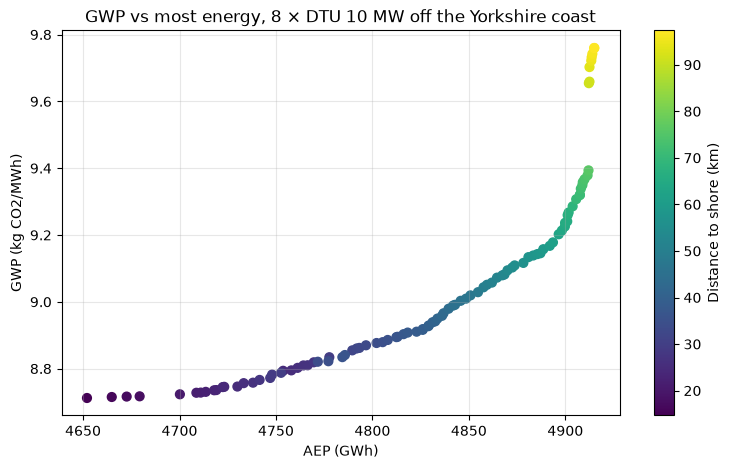

In [135]:
#@title Pareto front: GWP vs AEP

plt.figure(figsize=(9, 5))
sc = plt.scatter(front.AEP_GWh, front.GWP_MWh, c=front.Distance_to_shore_km, cmap="viridis", s=40)
plt.colorbar(sc, label="Distance to shore (km)")
plt.xlabel("AEP (GWh)"); plt.ylabel("GWP (kg CO2/MWh)")
plt.title("GWP vs most energy, 8 × DTU 10 MW off the Yorkshire coast")
plt.grid(True, alpha=0.3)
#plt.savefig(FIG / "06_pareto_lcoe_aep.png", dpi=150, bbox_inches="tight")
plt.show()

In [90]:
# Mapped cable type constants matching your exact CABLE_KG_PER_M.index variables
ARRAY_CABLE_TYPE = "array_66kV_3x400"

# Export system selection indexes matching your Ecoinvent/ABB inventory parameters
EXPORT_CABLE_HVAC = "export_132kV_3x300"    # or export_220kV_3x1000 depending on sizing profiles
EXPORT_CABLE_HVDC = "export_320kV_hvdc_pair" # Calibrated for deep-water links like Dogger Bank

def farm_impacts_new(array_km, export_km, n_turbines, capacity_mw):
    """
    Upgraded multi-layered Environmental Impact engine for dynamic layout optimization.

    Parameters:
        array_km (float): Total inter-array cabling layout (Minimum Spanning Tree length).
        export_km (float): Linear route parameter running out to sea (distance_to_shore).
        n_turbines (int): The current chromosome population count mask.
        capacity_mw (float): The variable capacity rating selected for this iteration.

    Returns:
        dict: Evaluated life cycle characterization scores spanning all active METHODS.
    """
    # 1. Compute dynamic turbine hardware masses and impacts live for the current capacity rating
    # (This automatically evaluates the Li et al. power laws for this layout iteration)
    live_turbine_impact = turbine_impacts(capacity_mw, foundation="jacket")

    # 2. Select the optimal transmission profile asset based on distance constraints
    # (Matches the commercial engineering transition rules established in Notebook 05)
    if export_km > 100:
        # Long distance projects like Dogger Bank switch to specialized bipolar HVDC pairs
        selected_export_cable = EXPORT_CABLE_HVDC
        export_share_multiplier = 1.0
    else:
        # Standard coastal configurations close to shore utilize HVAC infrastructure lines
        selected_export_cable = EXPORT_CABLE_HVAC
        export_share_multiplier = 1.0 # Or use dynamic sizing: (n_turbines * capacity_mw) / 300

    # 3. Aggregate total cradle-to-gate inventory impact profiles over the entire wind farm asset
    total_farm_metrics = {}
    for c in METHODS:
        # Component A: Total mass impacts for all active turbine stations
        station_footprint = n_turbines * live_turbine_impact[c]

        # Component B: Internal inter-array subsea cable matrix impact
        array_footprint = array_km * CABLE_IMPACT_PER_KM[ARRAY_CABLE_TYPE][c]

        # Component C: Main transmission export line impact to the mainland grid point
        export_footprint = export_km * export_share_multiplier * CABLE_IMPACT_PER_KM[selected_export_cable][c]

        # Sum components together programmatically for the current method evaluation loop
        total_farm_metrics[c] = station_footprint + array_footprint + export_footprint

    return total_farm_metrics


In [124]:
#@title Turbine models for each capacity (built once, then reused)
from functools import lru_cache
from py_wake.wind_turbines.generic_wind_turbines import GenericWindTurbine
from py_wake.site.shear import PowerShear

TARGET_MW = 80
C_MIN, C_MAX = 8, 12                          # validity range of the mass model
MAX_TURBINES = int(np.ceil(TARGET_MW / C_MIN)) # 10
SHEAR = PowerShear(h_ref=119, alpha=0.11)      # GWA data are at 119 m; alpha typical offshore

def n_turbines(C):
    return int(round(TARGET_MW / C))

@lru_cache(maxsize=None)
def turbine_model(C):
    D = rotor_diameter(C)
    H = hub_height(D)
    wt = GenericWindTurbine(f"Generic_{C}MW", diameter=D, hub_height=H, power_norm=C * 1000)  # kW
    wf = Niayifar_PorteAgel_2016(base_gwa_site, wt, turbulenceModel=CrespoHernandez())
    return wf, D, H

@lru_cache(maxsize=None)
def turbine_impacts_cached(C):
    return turbine_impacts(C)                  # per turbine, all categories

In [125]:
#@title Objective function (turbine size + layout + distance)
def unpack(v):
    C = int(np.round(v[0]))
    N = n_turbines(C)
    x = np.asarray(v[1 : 1 + MAX_TURBINES])[:N]                     # fixed slots
    y = np.asarray(v[1 + MAX_TURBINES : 1 + 2 * MAX_TURBINES])[:N]
    return C, N, x, y, v[-1]

def evaluate_design(v):
    """variables = [capacity MW, x1..x10, y1..y10, distance to shore km]
    Objectives: maximise full-load hours, minimise GWP per MWh."""
    C, N, x, y, dist_shore_km = unpack(v)
    wf, D, H = turbine_model(C)

    # Energy: wind scaled for distance offshore, sheared to this turbine's hub height
    scaled_ds = base_gwa_site.ds.copy(deep=True)
    scaled_ds["Weibull_A"] = base_gwa_site.ds["Weibull_A"] * calculate_transect_scale_factor(dist_shore_km)
    scaled_ds["TI"] = TI
    wf.site = XRSite(scaled_ds, shear=SHEAR)
    aep_gwh = float(wf(x + dist_shore_km * 1000, y).aep().sum().values)
    full_load_hours = aep_gwh * 1000 / (N * C)

    # Cables
    distances = pdist(np.column_stack([x, y]))
    array_km = minimum_spanning_tree(squareform(distances)).sum() / 1000
    export_km = dist_shore_km

    # Life cycle GWP per MWh
    t = turbine_impacts_cached(C)
    gwp_total = (N * t["GWP100"]
                 + array_km * CABLE_IMPACT_PER_KM[ARRAY_CABLE]["GWP100"]
                 + export_km * EXPORT_SHARE * CABLE_IMPACT_PER_KM[EXPORT_CABLE]["GWP100"])
    gwp_per_mwh = gwp_total / (aep_gwh * 1000 * LIFETIME_YR)

    spacing_violation = 4 * D - distances.min()
    return [-full_load_hours, gwp_per_mwh], spacing_violation

In [126]:
#@title Check each capacity once before optimising
x_pad = np.linspace(0, 2700, 5).repeat(2)        # 10 slots, spread over the lease box
y_pad = np.tile([0, 1800], 5)
for C in range(C_MIN, C_MAX + 1):
    v = np.concatenate([[C], x_pad, y_pad, [50]])
    (neg_flh, gwp), viol = evaluate_design(v)
    wf, D, H = turbine_model(C)
    print(f"{C:2d} MW x {n_turbines(C):2d} | D {D:5.1f} m, H {H:5.1f} m | "
          f"{-neg_flh:,.0f} full-load h | {gwp:5.2f} kg CO2e/MWh | spacing OK: {viol <= 0}")

 8 MW x 10 | D 163.2 m, H 116.1 m | 4,772 full-load h |  8.91 kg CO2e/MWh | spacing OK: True
 9 MW x  9 | D 172.2 m, H 120.0 m | 4,769 full-load h |  8.98 kg CO2e/MWh | spacing OK: False
10 MW x  8 | D 180.8 m, H 123.7 m | 4,766 full-load h |  9.07 kg CO2e/MWh | spacing OK: False
11 MW x  7 | D 188.9 m, H 127.1 m | 4,770 full-load h |  9.17 kg CO2e/MWh | spacing OK: False
12 MW x  7 | D 196.6 m, H 130.3 m | 4,761 full-load h |  9.18 kg CO2e/MWh | spacing OK: False


In [127]:
#@title NSGA-II problem
class WindFarmSizingProblem(ElementwiseProblem):
    def __init__(self):
        lower = [C_MIN] + [0] * MAX_TURBINES + [0] * MAX_TURBINES + [D_MIN_KM]
        upper = [C_MAX] + [LEASE_X] * MAX_TURBINES + [LEASE_Y] * MAX_TURBINES + [D_MAX_KM]
        super().__init__(n_var=len(lower),   # 1 + 10 + 10 + 1 = 22
                         n_obj=2,             # full-load hours, GWP per MWh
                         n_ieq_constr=1,      # spacing
                         xl=lower, xu=upper)

    def _evaluate(self, v, out, *args, **kwargs):
        objectives, spacing_violation = evaluate_design(v)
        out["F"] = objectives
        out["G"] = [spacing_violation]

In [129]:
#@title Run NSGA-II
problem = WindFarmSizingProblem()

rng = np.random.default_rng(SEED)
X0 = rng.uniform(problem.xl, problem.xu, size=(POP_SIZE, problem.n_var))
X0[0] = np.concatenate([[10], x_pad, y_pad, [D_REF_KM]])     # one feasible starting design

N_GEN = 300
POP_SIZE = 100

result = minimize(problem, NSGA2(pop_size=POP_SIZE, sampling=X0),
                  ("n_gen", N_GEN), seed=SEED, verbose=True)

rows = []
for v in result.X:
    C, N, x, y, d = unpack(v)
    (neg_flh, gwp), _ = evaluate_design(v)
    rows.append({"Capacity_MW": C, "N_turbines": N, "Distance_km": d,
                 "Full_load_hours": -neg_flh, "GWP_kg_per_MWh": gwp})
front = pd.DataFrame(rows).sort_values("GWP_kg_per_MWh").reset_index(drop=True)
print(front.round(2).to_string())

n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |       80 |      1 |  4.819974E+01 |  4.937075E+02 |             - |             -
     2 |      180 |      1 |  4.819974E+01 |  4.117905E+02 |             - |             -
     3 |      280 |      1 |  4.819974E+01 |  3.468634E+02 |             - |             -
     4 |      380 |      1 |  4.819974E+01 |  3.091955E+02 |             - |             -
     5 |      480 |      1 |  4.819974E+01 |  2.598924E+02 |             - |             -
     6 |      580 |      1 |  4.819974E+01 |  2.293423E+02 |             - |             -
     7 |      680 |      1 |  0.000000E+00 |  1.996579E+02 |             - |             -
     8 |      780 |      1 |  0.000000E+00 |  1.773383E+02 |  0.000000E+00 |             f
     9 |      880 |      1 |  0.000000E+00 |  1.548658E+02 |  0.000000E+00 |             f
    10 |      980 |      2 |  0.000000E+00 |  1.309661E+02 |  1.0000000000 |         ideal

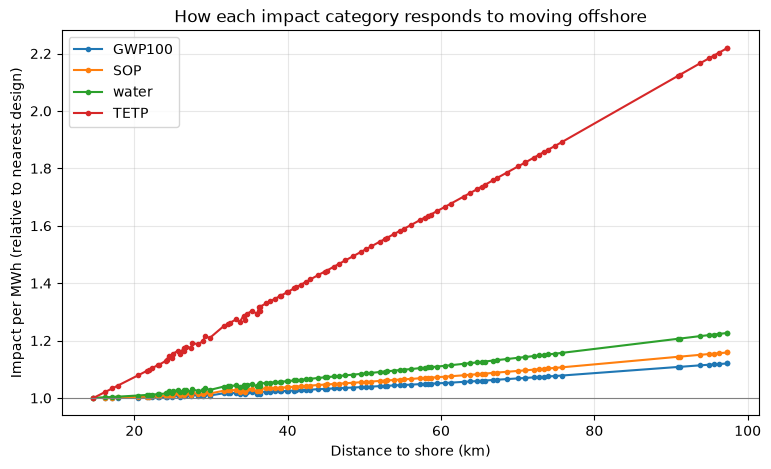

In [131]:
#@title All impact categories along the front
rows = []
for v in result.X:
    C, N, x, y, d = unpack(v)
    (neg_flh, _), _ = evaluate_design(v)
    aep_gwh = -neg_flh * N * C / 1000
    lifetime_mwh = aep_gwh * 1000 * LIFETIME_YR
    array_km = minimum_spanning_tree(squareform(pdist(np.column_stack([x, y])))).sum() / 1000
    t = turbine_impacts_cached(C)
    row = {"Capacity_MW": C, "Distance_km": d, "Full_load_hours": -neg_flh}
    for c in METHODS:
        total = (N * t[c]
                 + array_km * CABLE_IMPACT_PER_KM[ARRAY_CABLE][c]
                 + d * EXPORT_SHARE * CABLE_IMPACT_PER_KM[EXPORT_CABLE][c])
        row[f"{c}_per_MWh"] = total / lifetime_mwh
    rows.append(row)
impacts_front = pd.DataFrame(rows).sort_values("Distance_km").reset_index(drop=True)

# Each category relative to its value at the nearest-shore design
cols = [f"{c}_per_MWh" for c in METHODS]
rel = impacts_front[cols] / impacts_front[cols].iloc[0]

plt.figure(figsize=(9, 5))
for c in cols:
    plt.plot(impacts_front.Distance_km, rel[c], marker="o", ms=3, label=c.replace("_per_MWh", ""))
plt.axhline(1, color="grey", lw=0.8)
plt.xlabel("Distance to shore (km)"); plt.ylabel("Impact per MWh (relative to nearest design)")
plt.title("How each impact category responds to moving offshore")
plt.legend(); plt.grid(alpha=0.3)
#plt.savefig(FIG / "07_categories_vs_distance.png", dpi=150, bbox_inches="tight")
plt.show()